
# Example 6 — Class-conditional generation of weighted MNIST point clouds

This notebook implements a class-conditional generation experiment in the finite-dimensional conditioned diffusion framework of the manuscript.

We represent each normalized MNIST image as a weighted atomic probability measure


$$\mu_x = \sum_{i=1}^n s_i\,\delta_{\xi_i}$$

where the atoms are the centers of the `top_k` brightest pixels and the masses are the corresponding normalized pixel intensities. The masses are frozen, while the atom locations evolve under the conditioned diffusion.

The experiment has three moving parts:

1. **Measure representation.** Turn each image into a weighted point cloud / atomic measure.
2. **Terminal network.** Learn a positive terminal function
   $$ g_\theta(\mu, y) = \exp(f_\theta(\mu)_y) $$

   from labelled data, where `f_theta` is a weighted DeepSets classifier.
3. **Guided diffusion.** Use the learned terminal function inside the Doob `h`-transform and simulate the finite-dimensional drifted SDE.

The metrics we report are:

- terminal-network accuracy on generated samples,
- CAS-style score (train on synthetic only, test on real MNIST test set),
- 1-NN leave-one-out accuracy on real-vs-generated within each class,
- coverage via unique nearest real neighbours under Sinkhorn divergence,
- extra distance summaries: real→generated, generated→real, and generated diversity.



## Theory used in the code

Let `x = (x_1, ..., x_n)` be the current particle locations and `s = (s_1, ..., s_n)` the frozen mass vector.
The free finite-dimensional approximation has dynamics

$$ d\xi_i(t) = \sqrt{\frac{2}{s_i}}\,d\beta_i(t). $$


If `u_t(x, y)` is the backward heat evolution of the terminal weight `g_theta(·, y)`, then the conditioned drift is

$$ b_i(t, x; y) = 2 D_i \log u_t(x, y), \qquad D_i = \frac{1}{s_i}\nabla_{x_i} $$

For the free particle system we may write, with `\tau = T - t`,

$$ Y_i = x_i + \sqrt{\frac{2\tau}{s_i}} Z_i,
\qquad Z_i \sim N(0, I_2), $$

and therefore

$$
u_t(x, y) = \mathbb E[g_\theta(\Pi(Y), y)]. $$

Here `\Pi` is the canvas projection used in the notebook (`reflect`, `clip`, or `wrap`). Because the code evaluates the terminal network on `\Pi(Y)`, the exact terminal weight being conditioned on is `g_\theta \circ \Pi`.

Differentiating the Gaussian smoothing formula gives the drift identity

$$
b_i(t, x; y)
= \frac{1}{\tau}
\frac{\mathbb E[g_\theta(\Pi(Y), y)(Y_i - x_i)]}
{\mathbb E[g_\theta(\Pi(Y), y)]}.
$$

This is the quantity approximated by Monte Carlo in the generator.

### Practical note on the number of atoms

The free noise scale is `\sqrt{2\,dt/s_i}`. If we use too many atoms, the smallest masses become tiny and the diffusion gets very noisy. For that reason the notebook uses a moderate `top_k` and, if needed, a tiny mass floor before renormalization.


In [1]:

from __future__ import annotations

from pathlib import Path
import sys
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist_experiment6_fixes import (
    generate_balanced_synthetic_dataset_reparam,
    train_terminal_set_classifier_noisy,
)

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist_weighted_point_cloud import (
    WeightedPointCloudBatch,
    load_mnist_arrays,
    images_to_weighted_point_clouds,
    rasterize_weighted_point_clouds,
)
from mnist_conditioned_diffusion import (
    TerminalSetClassifier,
    train_terminal_set_classifier,
    evaluate_terminal_set_classifier,
    evaluate_generation_metrics,
)

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE)


device = cuda


In [2]:
FAST_DEMO = False

# Default generation starts from a genuinely synthetic state:
#   - uniform initial positions on the MNIST canvas
#   - truncated Poisson--Dirichlet masses
# Empirical-bank starts remain available as explicit ablations.

if FAST_DEMO:
    TRAIN_PER_CLASS = 512
    VAL_PER_CLASS = 128
    TEST_PER_CLASS = 256
    TOP_K = 24
    MASS_FLOOR = 1e-4

    TERMINAL_EPOCHS = 8
    TERMINAL_BATCH_SIZE = 256
    TERMINAL_LR = 2e-3
    POSITION_JITTER_STD = 2e-3

    SYNTHETIC_PER_CLASS = 128
    HORIZON = 5e-5
    STEP_SIZE = HORIZON / 100
    TERMINAL_MC_SAMPLES = 32
    GUIDANCE_SCALE = 3.0

    MASS_SAMPLING_MODE = 'truncated_poisson_dirichlet'
    CLASS_CONDITIONAL_MASS_SAMPLING = False
    POISSON_DIRICHLET_BETA = 2.0 * TOP_K
    POISSON_DIRICHLET_MAX_TERMS = None

    INITIAL_POSITION_MODE = 'uniform'
    INITIAL_POSITION_SCALE = 0.12
    INITIAL_POSITION_JITTER = 0.0
    JOINT_BANK_SAMPLING = False

    DRIFT_CLIP_NORM = None
    DRIFT_CLIP_TOTAL_DISPLACEMENT = 2.0 / 28.0

    CAS_EPOCHS = 6
    CAS_BATCH_SIZE = 128
    CAS_LR = 1e-3

    SINKHORN_SUBSAMPLE_PER_CLASS = 32
    SINKHORN_EPSILON = 0.02
    SINKHORN_ITERATIONS = 40
else:
    TRAIN_PER_CLASS = 5000
    VAL_PER_CLASS = 500
    TEST_PER_CLASS = 1000
    TOP_K = 32
    MASS_FLOOR = 1e-4

    TERMINAL_EPOCHS = 20
    TERMINAL_BATCH_SIZE = 256
    TERMINAL_LR = 1e-3
    POSITION_JITTER_STD = 2e-3

    SYNTHETIC_PER_CLASS = 1000
    HORIZON = 5e-5
    STEP_SIZE = HORIZON / 100
    TERMINAL_MC_SAMPLES = 128
    GUIDANCE_SCALE = 3.0

    MASS_SAMPLING_MODE = 'truncated_poisson_dirichlet'
    CLASS_CONDITIONAL_MASS_SAMPLING = False
    POISSON_DIRICHLET_BETA = 2.0 * TOP_K
    POISSON_DIRICHLET_MAX_TERMS = None

    INITIAL_POSITION_MODE = 'uniform'
    INITIAL_POSITION_SCALE = 0.12
    INITIAL_POSITION_JITTER = 0.0
    JOINT_BANK_SAMPLING = False

    DRIFT_CLIP_NORM = None
    DRIFT_CLIP_TOTAL_DISPLACEMENT = 2.0 / 28.0

    CAS_EPOCHS = 10
    CAS_BATCH_SIZE = 128
    CAS_LR = 1e-3

    SINKHORN_SUBSAMPLE_PER_CLASS = 64
    SINKHORN_EPSILON = 0.02
    SINKHORN_ITERATIONS = 50

DATA_ROOT = REPO_ROOT / 'mnist_data'
print('FAST_DEMO =', FAST_DEMO)
print('TOP_K =', TOP_K)
print('synthetic samples =', 10 * SYNTHETIC_PER_CLASS)
print('mass sampling mode =', MASS_SAMPLING_MODE)
print('initial position mode =', INITIAL_POSITION_MODE)
print('PD beta =', POISSON_DIRICHLET_BETA)
print('drift clip total displacement =', DRIFT_CLIP_TOTAL_DISPLACEMENT)



FAST_DEMO = False
TOP_K = 32
synthetic samples = 10000
mass sampling mode = truncated_poisson_dirichlet
initial position mode = uniform
PD beta = 64.0
drift clip total displacement = 0.07142857142857142



## Load MNIST and convert it to weighted point clouds

The loader optionally downloads the four raw IDX files if they are missing. We normalize every image to total mass one, because the state space in the manuscript is a space of probability measures.


In [3]:

mnist = load_mnist_arrays(DATA_ROOT, download=True, normalize_to_measure=True)

train_images_full = mnist['train_images']
train_labels_full = mnist['train_labels']
test_images_full = mnist['test_images']
test_labels_full = mnist['test_labels']

print('train images:', train_images_full.shape)
print('test images :', test_images_full.shape)




train images: (60000, 28, 28)
test images : (10000, 28, 28)


In [4]:
def class_counts(labels: np.ndarray) -> np.ndarray:
    return np.bincount(np.asarray(labels, dtype=np.int64), minlength=10)

def balanced_take(
    images: np.ndarray,
    labels: np.ndarray,
    per_class: int,
    *,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels, dtype=np.int64)
    selected = []
    for label in range(10):
        idx = np.flatnonzero(labels == label)
        if len(idx) < per_class:
            raise ValueError(
                f'label {label} only has {len(idx)} examples, need {per_class}. '
                f'Max balanced choice is {int(class_counts(labels).min())}.'
            )
        selected.append(rng.choice(idx, size=per_class, replace=False))
    selected_idx = np.concatenate(selected)
    rng.shuffle(selected_idx)
    return images[selected_idx], labels[selected_idx]

def balanced_train_val_split(
    images: np.ndarray,
    labels: np.ndarray,
    train_per_class: int,
    val_per_class: int,
    *,
    seed: int,
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels, dtype=np.int64)

    train_selected = []
    val_selected = []
    for label in range(10):
        idx = np.flatnonzero(labels == label)
        need = train_per_class + val_per_class
        if len(idx) < need:
            raise ValueError(
                f'label {label} only has {len(idx)} training examples, '
                f'need train+val={need}'
            )
        idx = rng.permutation(idx)
        train_selected.append(idx[:train_per_class])
        val_selected.append(idx[train_per_class:train_per_class + val_per_class])

    train_idx = np.concatenate(train_selected)
    val_idx = np.concatenate(val_selected)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return (images[train_idx], labels[train_idx]), (images[val_idx], labels[val_idx])

train_counts = class_counts(train_labels_full)
test_counts = class_counts(test_labels_full)

# Make train/val disjoint.
safe_train_per_class = TRAIN_PER_CLASS
max_train_per_class_disjoint = int(train_counts.min()) - VAL_PER_CLASS
if safe_train_per_class > max_train_per_class_disjoint:
    safe_train_per_class = max_train_per_class_disjoint
    print(
        f'Requested TRAIN_PER_CLASS={TRAIN_PER_CLASS} with VAL_PER_CLASS={VAL_PER_CLASS}, '
        f'but the smallest training class has only {int(train_counts.min())} examples. '
        f'Using TRAIN_PER_CLASS={safe_train_per_class} so train/val stay disjoint.'
    )

(train_images, train_labels), (val_images, val_labels) = balanced_train_val_split(
    train_images_full,
    train_labels_full,
    safe_train_per_class,
    VAL_PER_CLASS,
    seed=SEED,
)

# Balanced test subset: cap automatically at the smallest test-class count.
safe_test_per_class = min(TEST_PER_CLASS, int(test_counts.min()))
if safe_test_per_class < TEST_PER_CLASS:
    print(
        f'Requested TEST_PER_CLASS={TEST_PER_CLASS}, but the smallest test class has '
        f'{int(test_counts.min())} examples. Using {safe_test_per_class} per class instead.'
    )

real_test_images, real_test_labels = balanced_take(
    test_images_full,
    test_labels_full,
    safe_test_per_class,
    seed=SEED + 2,
)

train_pc = images_to_weighted_point_clouds(train_images, labels=train_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)
val_pc = images_to_weighted_point_clouds(val_images, labels=val_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)
real_test_pc = images_to_weighted_point_clouds(real_test_images, labels=real_test_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)

print('train counts      :', train_counts)
print('test counts       :', test_counts)
print('train point clouds:', train_pc.masses.shape, train_pc.positions.shape)
print('val point clouds  :', val_pc.masses.shape, val_pc.positions.shape)
print('balanced test use :', safe_test_per_class, 'per class')

Requested TRAIN_PER_CLASS=5000 with VAL_PER_CLASS=500, but the smallest training class has only 5421 examples. Using TRAIN_PER_CLASS=4921 so train/val stay disjoint.
Requested TEST_PER_CLASS=1000, but the smallest test class has 892 examples. Using 892 per class instead.
train counts      : [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
test counts       : [ 980 1135 1032 1010  982  892  958 1028  974 1009]
train point clouds: (49210, 32) (49210, 32, 2)
val point clouds  : (5000, 32) (5000, 32, 2)
balanced test use : 892 per class


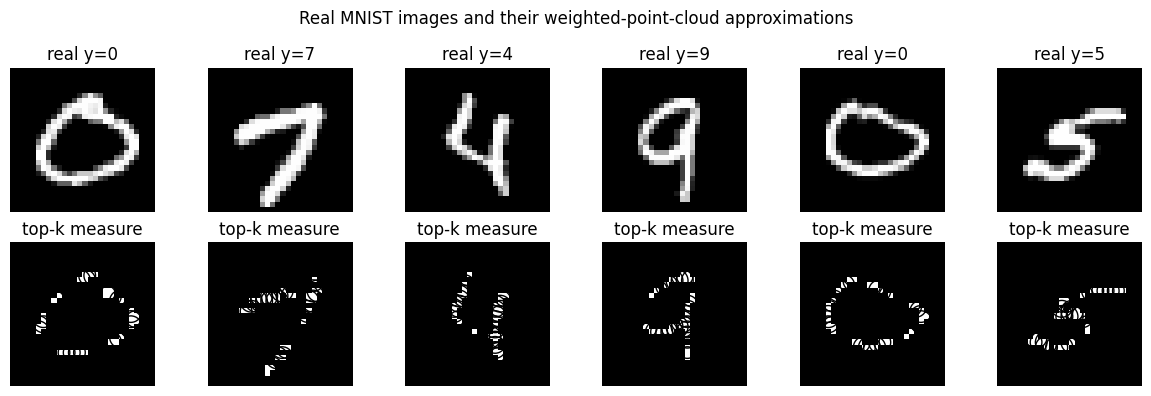

In [5]:

def show_real_reconstructions(batch: WeightedPointCloudBatch, count: int = 6) -> None:
    idx = np.arange(min(count, len(batch)))
    recon = rasterize_weighted_point_clouds(batch.masses[idx], batch.positions[idx])

    fig, axes = plt.subplots(2, len(idx), figsize=(2.0 * len(idx), 4.0))
    for j, i in enumerate(idx):
        axes[0, j].imshow(batch.images[i], cmap='gray')
        axes[0, j].set_title(f'real y={int(batch.labels[i])}')
        axes[0, j].axis('off')

        axes[1, j].imshow(recon[j], cmap='gray')
        axes[1, j].scatter(
            batch.positions[i, :, 0] * 28 - 0.5,
            batch.positions[i, :, 1] * 28 - 0.5,
            s=250.0 * batch.masses[i] / batch.masses[i].max(),
            edgecolors='black',
            facecolors='none',
        )
        axes[1, j].set_title('top-k measure')
        axes[1, j].axis('off')
    fig.suptitle('Real MNIST images and their weighted-point-cloud approximations')
    plt.tight_layout()

show_real_reconstructions(train_pc, count=6)



## Train the terminal network `g_\theta(\mu, y)`

We train a weighted DeepSets classifier on the point-cloud representation. The learned class logit is then exponentiated to obtain the positive terminal weight used by the `h`-transform.


In [6]:

terminal_model = TerminalSetClassifier(point_feature_dim=128, hidden_dim=256, num_classes=10)

terminal_history = train_terminal_set_classifier_noisy(
    terminal_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    epochs=TERMINAL_EPOCHS,
    batch_size=TERMINAL_BATCH_SIZE,
    lr=TERMINAL_LR,
    position_jitter_std=POSITION_JITTER_STD,
    max_tau=HORIZON,
    projection="reflect",
    device=DEVICE,
    verbose=True,
)

train_metrics = evaluate_terminal_set_classifier(
    terminal_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    device=DEVICE,
)
val_metrics = evaluate_terminal_set_classifier(
    terminal_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    device=DEVICE,
)

print('terminal train accuracy =', train_metrics['accuracy'])
print('terminal val accuracy   =', val_metrics['accuracy'])


[terminal noisy] epoch 001/020: train loss = 1.8557, train acc = 0.3118, val loss = 1.1552, val acc = 0.5934
[terminal noisy] epoch 002/020: train loss = 1.2155, train acc = 0.5671, val loss = 0.9784, val acc = 0.6654
[terminal noisy] epoch 003/020: train loss = 1.0598, train acc = 0.6218, val loss = 0.7614, val acc = 0.7412
[terminal noisy] epoch 004/020: train loss = 0.9978, train acc = 0.6500, val loss = 0.7193, val acc = 0.7582
[terminal noisy] epoch 005/020: train loss = 0.9358, train acc = 0.6710, val loss = 0.7027, val acc = 0.7590
[terminal noisy] epoch 006/020: train loss = 0.8808, train acc = 0.6892, val loss = 0.6505, val acc = 0.7746
[terminal noisy] epoch 007/020: train loss = 0.8488, train acc = 0.7049, val loss = 0.5975, val acc = 0.8000
[terminal noisy] epoch 008/020: train loss = 0.8126, train acc = 0.7147, val loss = 0.6705, val acc = 0.7702
[terminal noisy] epoch 009/020: train loss = 0.7909, train acc = 0.7251, val loss = 0.5310, val acc = 0.8232
[terminal noisy] ep

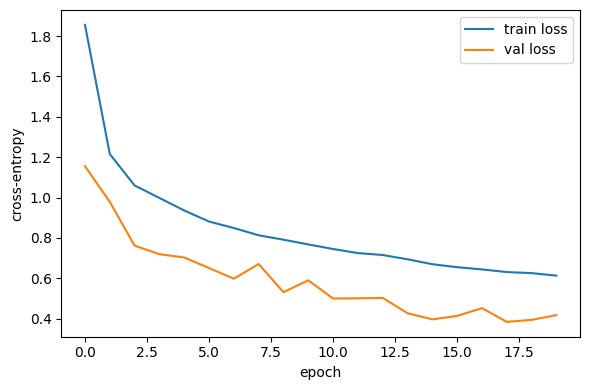

In [7]:

fig = plt.figure(figsize=(6, 4))
plt.plot(terminal_history['train_loss'], label='train loss')
plt.plot(terminal_history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('cross-entropy')
plt.legend()
plt.tight_layout()


## Generate synthetic weighted point clouds

For each target label `y`, the generator:

1. samples a frozen mass vector either from the empirical bank or from a truncated Poisson--Dirichlet law,
2. initializes the particle locations either from an empirical point-cloud bank or from a synthetic canvas prior,
3. estimates the conditioned drift by low-variance reparameterized Monte Carlo terminal sampling,
4. advances the particle system with Euler--Maruyama.

The default configuration now uses an *honest* synthetic start: uniform locations on the unit square together with truncated Poisson--Dirichlet masses. Empirical-bank starts remain available as ablations.


In [8]:
initial_position_bank = train_pc.positions if INITIAL_POSITION_MODE == 'bank' else None
initial_position_bank_labels = train_pc.labels if INITIAL_POSITION_MODE == 'bank' else None
mass_bank = train_pc.masses if MASS_SAMPLING_MODE == 'bank' else None
mass_bank_labels = train_pc.labels if MASS_SAMPLING_MODE == 'bank' else None

synthetic = generate_balanced_synthetic_dataset_reparam(
    terminal_model,
    mass_bank,
    bank_labels=mass_bank_labels,
    num_points=TOP_K,
    num_per_class=SYNTHETIC_PER_CLASS,
    mass_sampling_mode=MASS_SAMPLING_MODE,
    class_conditional_mass_sampling=CLASS_CONDITIONAL_MASS_SAMPLING,
    poisson_dirichlet_beta=POISSON_DIRICHLET_BETA,
    poisson_dirichlet_max_terms=POISSON_DIRICHLET_MAX_TERMS,
    horizon=HORIZON,
    step_size=STEP_SIZE,
    terminal_mc_samples=TERMINAL_MC_SAMPLES,
    guidance_scale=GUIDANCE_SCALE,
    initial_position_mode=INITIAL_POSITION_MODE,
    initial_position_scale=INITIAL_POSITION_SCALE,
    initial_position_bank=initial_position_bank,
    initial_position_bank_labels=initial_position_bank_labels,
    joint_bank_sampling=JOINT_BANK_SAMPLING,
    initial_position_jitter=INITIAL_POSITION_JITTER,
    state_projection='reflect',
    terminal_projection='reflect',
    drift_clip_norm=DRIFT_CLIP_NORM,
    drift_clip_total_displacement=DRIFT_CLIP_TOTAL_DISPLACEMENT,
    batch_size=64,
    rasterize=True,
    image_size=28,
    device=DEVICE,
    rng=np.random.default_rng(SEED),
)

print('synthetic positions:', synthetic.positions.shape)
print('synthetic images   :', synthetic.images.shape)



synthetic positions: (10000, 32, 2)
synthetic images   : (10000, 28, 28)


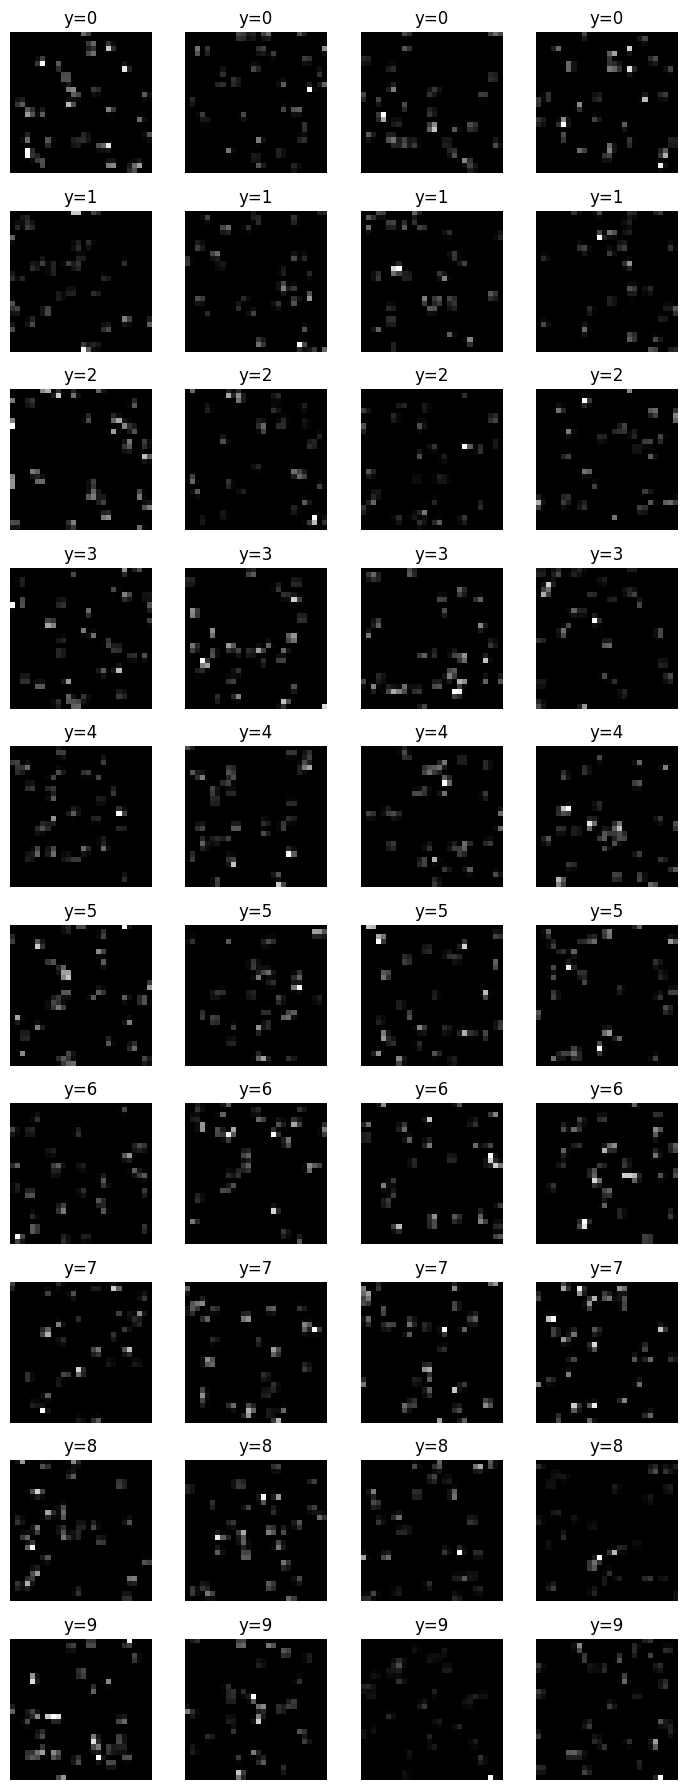

In [9]:

def show_synthetic_examples(generated, count_per_class: int = 4) -> None:
    fig, axes = plt.subplots(10, count_per_class, figsize=(1.8 * count_per_class, 18))
    for label in range(10):
        idx = np.flatnonzero(generated.labels == label)[:count_per_class]
        for j, i in enumerate(idx):
            axes[label, j].imshow(generated.images[i], cmap='gray')
            axes[label, j].set_title(f'y={label}')
            axes[label, j].axis('off')
    plt.tight_layout()

show_synthetic_examples(synthetic, count_per_class=4)



## Evaluation

We report the requested metrics.

- **`g`-accuracy.** Percent of generated samples whose predicted class under `argmax_y g_\theta(\mu, y)` matches the target label.
- **CAS.** Train a fresh image classifier **only on synthetic data** and evaluate it on the real MNIST test set.
- **1-NN LOO.** Real-vs-generated leave-one-out 1-nearest-neighbour accuracy within each class, using the Sinkhorn divergence. A value near **50%** indicates that real and generated samples are hard to separate.
- **Coverage.** Fraction of unique nearest real neighbours hit by the generated set in each class.
- **Extra metrics.** Mean real→generated and generated→real Sinkhorn distances, plus a generated-diversity score.


In [10]:

metrics = evaluate_generation_metrics(
    terminal_model,
    synthetic,
    real_test_pc,
    real_test_images,
    real_test_labels,
    cas_epochs=CAS_EPOCHS,
    cas_batch_size=CAS_BATCH_SIZE,
    cas_lr=CAS_LR,
    sinkhorn_epsilon=SINKHORN_EPSILON,
    sinkhorn_iterations=SINKHORN_ITERATIONS,
    sinkhorn_subsample_per_class=SINKHORN_SUBSAMPLE_PER_CLASS,
    device=DEVICE,
    rng=np.random.default_rng(SEED),
    verbose=True,
)

summary = {
    'g_accuracy': metrics['g_accuracy'],
    'g_mean_target_probability': metrics['g_mean_target_probability'],
    'cas_accuracy': metrics['cas_accuracy'],
    'one_nn_accuracy_macro': metrics['one_nn_accuracy_macro'],
    'coverage_macro': metrics['coverage_macro'],
    'mean_real_to_generated_sinkhorn_macro': metrics['mean_real_to_generated_sinkhorn_macro'],
    'mean_generated_to_real_sinkhorn_macro': metrics['mean_generated_to_real_sinkhorn_macro'],
    'mean_generated_diversity_macro': metrics['mean_generated_diversity_macro'],
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['value']
summary_df


[CAS] epoch 001/010: train loss = 2.3038, train acc = 0.0976
[CAS] epoch 002/010: train loss = 2.3035, train acc = 0.0967
[CAS] epoch 003/010: train loss = 2.3031, train acc = 0.0944
[CAS] epoch 004/010: train loss = 2.3032, train acc = 0.0944
[CAS] epoch 005/010: train loss = 2.3032, train acc = 0.0943
[CAS] epoch 006/010: train loss = 2.3030, train acc = 0.0972
[CAS] epoch 007/010: train loss = 2.3029, train acc = 0.0948
[CAS] epoch 008/010: train loss = 2.3029, train acc = 0.0959
[CAS] epoch 009/010: train loss = 2.3029, train acc = 0.0916
[CAS] epoch 010/010: train loss = 2.3028, train acc = 0.1007


,value
g_accuracy,0.279300
g_mean_target_probability,0.246107
cas_accuracy,0.100000
one_nn_accuracy_macro,0.996094
coverage_macro,0.221875
mean_real_to_generated_sinkhorn_macro,0.037226
mean_generated_to_real_sinkhorn_macro,0.044092
mean_generated_diversity_macro,0.019202


In [11]:

per_label_df = pd.DataFrame(metrics['per_label']).T.sort_index()
per_label_df.index.name = 'label'
per_label_df


,one_nn_accuracy,coverage,mean_real_to_generated_sinkhorn,mean_generated_to_real_sinkhorn,mean_generated_diversity
label,,,,,
0,0.984375,0.281250,0.030117,0.033258,0.018558
1,1.000000,0.093750,0.051910,0.069639,0.019560
2,0.992188,0.250000,0.040102,0.042536,0.020146
3,1.000000,0.218750,0.035559,0.038913,0.019678
4,0.992188,0.234375,0.035233,0.044259,0.019255
5,0.992188,0.203125,0.036069,0.039618,0.019416
6,1.000000,0.265625,0.037071,0.040917,0.018539
7,1.000000,0.250000,0.037899,0.044337,0.019423
8,1.000000,0.218750,0.034823,0.041965,0.018376



## Reading the results

A typical healthy outcome has the following qualitative pattern:

- **high `g`-accuracy:** the terminal network agrees that the generated sample belongs to the requested class,
- **good CAS score:** a classifier trained on synthetic images transfers to real MNIST,
- **1-NN close to 0.5:** real and generated sets are hard to separate,
- **high coverage:** many distinct real modes are matched by generated samples,
- **reasonable generated diversity:** the synthetic set is not collapsing to a tiny family of point clouds.

### Suggested ablations

Useful ablations for the paper version of the experiment are:

1. `top_k` in `{16, 24, 32}`,
2. class-conditional vs class-agnostic mass-bank sampling,
3. `guidance_scale`,
4. terminal Monte Carlo sample count,
5. projection mode (`reflect`, `clip`, `wrap`),
6. Sinkhorn regularization `epsilon` in the metrics.
